# **EduPulse – Student Dropout Risk Prediction**

Notebook ini mendokumentasikan proses end-to-end pengembangan fitur tambahan EduPulse, mulai dari pemahaman masalah bisnis, data wrangling, EDA, visualisasi, pemodelan, evaluasi, hingga penyediaan model dan fungsi prediksi.

**Tujuan utama:** memprediksi apakah seorang siswa memiliki risiko dropout berdasarkan faktor akademik, kehadiran, kebiasaan belajar, kondisi sosial, dan faktor pendukung lainnya.

## **Informasi Dataset**

Dataset yang digunakan berisi **10.000 data siswa dengan 19 kolom** yang mencakup karakteristik demografis, kondisi ekonomi, kebiasaan belajar, kehadiran, performa akademik, dan status dropout.

Target pemodelan adalah **Dropout**, dengan:
- `0` = Not Dropout
- `1` = Dropout

### Sumber dan Lisensi Dataset

Dataset diperoleh dari Kaggle melalui **Student Dropout Prediction Dataset**.

**Source:**  
https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset

**License:** CC0: Public Domain

# **1. Business Understanding**

### Business Problem

Sekolah membutuhkan pendekatan berbasis data untuk mengidentifikasi siswa
yang berpotensi mengalami dropout sejak dini agar dapat dilakukan pemantauan
dan intervensi yang lebih tepat.

Dalam proses pemantauan siswa, informasi mengenai performa akademik,
kehadiran, kebiasaan belajar, kondisi stres, serta faktor pendukung lainnya
dapat digunakan sebagai dasar untuk membantu mengidentifikasi siswa yang
membutuhkan perhatian lebih awal.

### Business Problems

1. Sekolah dapat mengalami keterlambatan dalam mengidentifikasi siswa
   yang mulai menunjukkan risiko dropout.

2. Proses monitoring siswa dapat menjadi kurang efisien ketika jumlah
   siswa cukup besar karena membutuhkan pemeriksaan terhadap banyak
   indikator secara manual.

3. Sekolah membutuhkan informasi pendukung untuk menentukan siswa
   yang perlu mendapatkan perhatian dan intervensi lebih awal.

### Business Questions

1. **Bagaimana pola indikator siswa, seperti kehadiran dan kebiasaan belajar,
   berkaitan dengan perbedaan dropout rate?**

2. **Indikator apa saja yang paling informatif untuk digunakan dalam
   memprediksi risiko dropout siswa?**

3. **Model Machine Learning dan konfigurasi fitur seperti apa yang sesuai
   untuk mendukung kebutuhan EduPulse sebagai early warning system?**

### Proposed Solution

EduPulse dikembangkan sebagai sistem early warning berbasis data yang
menggunakan model Machine Learning untuk memprediksi risiko dropout siswa.

Solusi yang digunakan adalah model klasifikasi yang memprediksi probabilitas
seorang siswa mengalami dropout berdasarkan karakteristik dan faktor yang
tersedia pada dataset. Hasil prediksi kemudian digunakan sebagai informasi
pendukung untuk membantu proses monitoring dan menentukan siswa yang
membutuhkan perhatian lebih awal.

### Business Needs

Kebutuhan bisnis yang ingin didukung oleh EduPulse meliputi:

1. Mengidentifikasi siswa yang memiliki risiko dropout sejak dini.

2. Memahami indikator siswa yang memiliki hubungan dengan status dropout.

3. Mendukung proses monitoring terhadap siswa yang membutuhkan perhatian
   lebih lanjut.

4. Menyediakan hasil prediksi yang mudah dipahami dan dapat digunakan
   sebagai informasi pendukung untuk proses intervensi awal.

### Data Requirements

Dataset yang digunakan berisi 10.000 data siswa dengan 19 kolom yang
mencakup karakteristik siswa, kondisi ekonomi, kebiasaan belajar, kehadiran,
performa akademik, dan faktor pendukung lainnya.

Target pemodelan adalah `Dropout`, dengan:

- `0` = Not Dropout
- `1` = Dropout

Untuk kebutuhan integrasi antara aplikasi dan Machine Learning, digunakan
enam fitur utama sebagai input Lightweight Model, yaitu:

- `GPA`
- `Stress_Index`
- `Attendance_Rate`
- `Study_Hours_per_Day`
- `Travel_Time_Minutes`
- `Assignment_Delay_Days`

Enam fitur tersebut digunakan sebagai input utama karena lebih sederhana
dan praktis untuk diintegrasikan dengan aplikasi EduPulse.

### Prediction Output

Hasil prediksi yang digunakan dalam aplikasi terdiri dari:

- **Dropout Probability**, yaitu probabilitas seorang siswa mengalami dropout.
- **Risk Level**, yaitu kategori risiko yang terdiri dari **Low Risk**,
  **Medium Risk**, dan **High Risk** berdasarkan threshold yang telah
  ditentukan.

Output tersebut digunakan sebagai informasi pendukung untuk membantu proses
identifikasi dan monitoring siswa yang membutuhkan perhatian lebih awal.

# **2. Import Library**

Seluruh library yang digunakan dalam proses analisis, visualisasi, preprocessing, evaluasi, pemodelan, dan penyimpanan model disiapkan pada bagian ini.

In [1]:
# Library untuk analisis data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import sklearn
import joblib

# Library untuk preprocessing dan machine learning
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    learning_curve
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Model klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Library untuk evaluasi model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

### **Referensi Library dan Model**

#### Library
Library yang digunakan dalam proyek ini meliputi:

- **Pandas** — https://pandas.pydata.org/
- **NumPy** — https://numpy.org/
- **Matplotlib** — https://matplotlib.org/
- **Seaborn** — https://seaborn.pydata.org/
- **Scikit-learn** — https://scikit-learn.org/
- **Joblib** — https://joblib.readthedocs.io/

Penggunaan library mengikuti lisensi dan ketentuan penggunaan yang ditetapkan oleh masing-masing proyek.

#### Machine Learning Model
Model utama yang digunakan adalah **Logistic Regression** dari Scikit-learn.

**Documentation:**  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Implementasi model mengikuti lisensi dan ketentuan penggunaan Scikit-learn.

# **3. Data Gathering**

Dataset dimuat untuk memahami struktur, karakteristik, dan kondisi awal data sebelum memasuki tahap Data Cleaning.

Pada tahap ini dilakukan pemeriksaan terhadap ukuran dataset, struktur dan tipe data, missing value, data duplikat, nilai kategorikal, serta statistik deskriptif untuk memperoleh gambaran awal mengenai dataset yang digunakan.

In [2]:
df = pd.read_csv("student_dropout_dataset_v3.csv")

## **3.1 Ukuran Dataset**

In [3]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 10000
Jumlah kolom : 19


### Insight

Dataset yang digunakan terdiri dari **10.000 baris dan 19 kolom**. Data tersebut mencakup berbagai informasi siswa yang akan digunakan untuk memahami karakteristik siswa dan mendukung proses pemodelan risiko dropout.

## **3.2 Struktur dan Tipe Data**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

### Insight

Dataset terdiri dari **19 variabel** dengan kombinasi tipe data numerik dan kategorikal. Beberapa variabel seperti `GPA`, `Attendance_Rate`, `Study_Hours_per_Day`, dan `Stress_Index` memiliki tipe numerik, sedangkan variabel seperti `Gender`, `Internet_Access`, `Part_Time_Job`, `Scholarship`, `Semester`, `Department`, dan `Parental_Education` merupakan variabel kategorikal.

Hasil pemeriksaan juga menunjukkan adanya missing value pada beberapa variabel, yang akan ditangani pada tahap **Data Cleaning**.

## **3.3 Pemeriksaan Missing Value**

In [5]:
missing_summary = df.isnull().sum().to_frame("missing_value")
missing_summary["missing_percentage"] = (
    missing_summary["missing_value"] / len(df) * 100
).round(2)

missing_summary[missing_summary["missing_value"] > 0].sort_values(
    "missing_value", ascending=False
)

,missing_value,missing_percentage
Parental_Education,511,5.11
Family_Income,500,5.00
Study_Hours_per_Day,500,5.00
Stress_Index,500,5.00


### Insight

Hasil pemeriksaan menunjukkan terdapat missing value pada empat variabel, yaitu:

- `Parental_Education` sebanyak **511 data (5,11%)**
- `Family_Income` sebanyak **500 data (5,00%)**
- `Study_Hours_per_Day` sebanyak **500 data (5,00%)**
- `Stress_Index` sebanyak **500 data (5,00%)**

Missing value tersebut akan ditangani pada tahap **Data Cleaning** tanpa menghapus baris data secara langsung agar jumlah observasi tetap dapat dipertahankan.

Pemeriksaan missing value dilakukan untuk mengetahui variabel yang memiliki data kosong sebelum proses cleaning. Nilai yang ditemukan akan ditangani pada tahap Data Cleaning dengan metode yang sesuai berdasarkan tipe datanya.

## **3.4 Pemeriksaan Data Duplikat**

In [6]:
print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah data duplikat : 0


### Insight

Hasil pemeriksaan menunjukkan bahwa **tidak terdapat data duplikat** pada dataset. Dengan demikian, tidak diperlukan proses penghapusan data berdasarkan duplikasi pada tahap Data Cleaning.

## **3.5 Pemeriksaan Nilai Kategorikal**

In [7]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Gender
Gender
Female    5011
Male      4989
Name: count, dtype: int64

Internet_Access
Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

Part_Time_Job
Part_Time_Job
No     5996
Yes    4004
Name: count, dtype: int64

Scholarship
Scholarship
No     6489
Yes    3511
Name: count, dtype: int64

Semester
Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455
Name: count, dtype: int64

Department
Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937
Name: count, dtype: int64

Parental_Education
Parental_Education
Bachelor       3949
High School    3072
Master         2003
NaN             511
PhD             465
Name: count, dtype: int64


### Insight

Pemeriksaan nilai kategorikal dilakukan untuk memahami variasi kategori pada variabel bertipe kategorikal serta memastikan tidak terdapat kategori yang tidak sesuai dengan karakteristik data.

Beberapa variabel memiliki dua kategori, seperti `Gender`, `Internet_Access`, `Part_Time_Job`, dan `Scholarship`. Sementara itu, `Semester` memiliki empat kategori dan `Department` memiliki lima kategori.

Pada `Parental_Education`, terdapat nilai kosong yang konsisten dengan hasil pemeriksaan missing value sebelumnya. Nilai tersebut akan ditangani pada tahap Data Cleaning.

## **3.6 Statistik Deskriptif dan Rentang Data**

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Age,10000.0,NaN,NaN,NaN,21.02606,2.13981,17.0,19.5,21.0,22.5,29.6
Gender,10000,2,Female,5011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family_Income,9500.0,NaN,NaN,NaN,38377.247474,20496.232179,25000.0,25000.0,29740.5,44520.0,316601.0
Internet_Access,10000,2,Yes,8769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Study_Hours_per_Day,9500.0,NaN,NaN,NaN,4.014592,1.29545,0.5,3.16,4.0,4.87,8.98
Attendance_Rate,10000.0,NaN,NaN,NaN,81.73683,8.22093,38.2,76.4,81.8,87.3,100.0
Assignment_Delay_Days,10000.0,NaN,NaN,NaN,1.7997,1.344307,0.0,1.0,2.0,3.0,8.0
Travel_Time_Minutes,10000.0,NaN,NaN,NaN,30.17926,11.91887,5.0,21.9,30.2,38.4,74.9
Part_Time_Job,10000,2,No,5996,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Insight

Statistik deskriptif digunakan untuk memahami distribusi awal variabel numerik pada dataset.

Beberapa variabel utama yang digunakan dalam analisis memiliki karakteristik sebagai berikut:

- `GPA` memiliki rentang nilai **0–4** dengan rata-rata sekitar **2,31**.
- `Attendance_Rate` memiliki rentang **38,2%–100%** dengan rata-rata sekitar **81,74%**.
- `Study_Hours_per_Day` memiliki rentang **0,5–8,98 jam** dengan rata-rata sekitar **4,01 jam/hari**.
- `Stress_Index` memiliki rentang **1–10** dengan rata-rata sekitar **5,51**.
- `Assignment_Delay_Days` memiliki rentang **0–8 hari** dengan rata-rata sekitar **1,80 hari**.
- `Travel_Time_Minutes` memiliki rentang **5–74,9 menit** dengan rata-rata sekitar **30,18 menit**.

Rentang tersebut memberikan gambaran awal mengenai kondisi data dan menjadi dasar untuk pemeriksaan lebih lanjut pada tahap Data Cleaning, termasuk pemeriksaan potensi outlier.

In [9]:
numeric_assessment = df.select_dtypes(include=np.number).describe().T
numeric_assessment[["min", "max", "mean", "std"]]

,min,max,mean,std
Student_ID,1.0,10000.00,5000.500000,2886.895680
Age,17.0,29.60,21.026060,2.139810
Family_Income,25000.0,316601.00,38377.247474,20496.232179
Study_Hours_per_Day,0.5,8.98,4.014592,1.295450
Attendance_Rate,38.2,100.00,81.736830,8.220930
Assignment_Delay_Days,0.0,8.00,1.799700,1.344307
Travel_Time_Minutes,5.0,74.90,30.179260,11.918870
Stress_Index,1.0,10.00,5.507147,1.765951
GPA,0.0,4.00,2.308440,1.061717
Semester_GPA,0.0,4.00,2.300057,1.074407


Hasil assessment digunakan sebagai dasar untuk menentukan tindakan cleaning. Pemeriksaan mencakup missing value, duplikasi, tipe data, kategori, serta rentang dan statistik variabel numerik.

# **4. Data Cleaning**

Tahap Data Cleaning dilakukan berdasarkan hasil pemeriksaan awal pada dataset. Proses ini bertujuan untuk memastikan data memiliki kondisi yang sesuai sebelum digunakan pada tahap Exploratory Data Analysis dan pemodelan.

Tahapan cleaning yang dilakukan meliputi:

1. Menangani missing value pada variabel numerik dan kategorikal.
2. Memvalidasi tipe data setiap variabel.
3. Memeriksa data duplikat.
4. Mengidentifikasi potensi outlier menggunakan metode Interquartile Range (IQR).
5. Memverifikasi kembali kondisi dataset setelah proses cleaning.

Pada pemeriksaan outlier, nilai yang teridentifikasi tidak langsung dihapus. Nilai ekstrem dipertahankan apabila masih masuk akal secara konteks karena dapat merepresentasikan kondisi siswa yang valid.

## **4.1 Handling Missing Value**

In [10]:
# Menentukan kolom berdasarkan tipe data
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

# Target tidak termasuk proses imputasi
numeric_features = [col for col in numeric_cols if col != "Dropout"]

# Menyimpan jumlah missing sebelum cleaning
missing_before = df.isnull().sum()

# Imputasi numerik dengan median
for col in numeric_features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Imputasi kategorikal dengan modus
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

missing_after = df.isnull().sum()

cleaning_missing_summary = pd.DataFrame({
    "missing_before": missing_before,
    "missing_after": missing_after
})

cleaning_missing_summary[cleaning_missing_summary["missing_before"] > 0]

,missing_before,missing_after
Family_Income,500,0
Study_Hours_per_Day,500,0
Stress_Index,500,0
Parental_Education,511,0


### Insight

Missing value ditemukan pada empat variabel, yaitu `Family_Income`, `Study_Hours_per_Day`, `Stress_Index`, dan `Parental_Education`.

Untuk variabel numerik digunakan **median**, sedangkan variabel kategorikal menggunakan **modus**. Pendekatan ini digunakan untuk mempertahankan seluruh baris data tanpa menghapus observasi yang masih dapat digunakan.

Hasil setelah proses imputasi menunjukkan bahwa seluruh missing value telah berhasil ditangani, dengan jumlah missing value pada keempat variabel menjadi **0**.

## **4.2 Validasi Tipe Data**

In [11]:
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="raise")

df["Dropout"] = pd.to_numeric(df["Dropout"], errors="raise").astype(int)

print(df.dtypes)

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object


### Insight

Validasi tipe data dilakukan untuk memastikan setiap variabel memiliki tipe data yang sesuai dengan karakteristiknya.

Variabel numerik dikonversi menggunakan tipe numerik, sedangkan target `Dropout` dikonversi menjadi tipe integer. Proses validasi dilakukan dengan `errors="raise"` sehingga nilai yang tidak dapat dikonversi akan terdeteksi sebagai error.

Hasil pemeriksaan menunjukkan bahwa tidak terdapat masalah tipe data pada dataset setelah proses validasi.

## **4.3 Pemeriksaan Data Duplikat**

In [12]:
duplicate_count = df.duplicated().sum()
print("Jumlah data duplikat :", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Jumlah baris setelah menghapus duplikat :", df.shape[0])
else:
    print("Tidak ada data duplikat yang perlu dihapus.")

Jumlah data duplikat : 0
Tidak ada data duplikat yang perlu dihapus.


### Insight

Pemeriksaan duplikat dilakukan untuk memastikan tidak terdapat observasi yang tercatat lebih dari satu kali.

Hasil pemeriksaan menunjukkan terdapat **0 data duplikat**, sehingga tidak ada baris yang perlu dihapus pada tahap ini.

## **4.4 Pemeriksaan Outlier dengan IQR**

In [13]:
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values("outlier_count", ascending=False)

,column,Q1,Q3,lower_bound,upper_bound,outlier_count
2,Family_Income,25000.00,43361.75,-2542.625,70904.375,683
3,Study_Hours_per_Day,3.21,4.81,0.810,7.210,138
7,Stress_Index,4.40,6.60,1.100,9.900,137
4,Attendance_Rate,76.40,87.30,60.050,103.650,57
1,Age,19.50,22.50,15.000,27.000,33
6,Travel_Time_Minutes,21.90,38.40,-2.850,63.150,25
5,Assignment_Delay_Days,1.00,3.00,-2.000,6.000,25
0,Student_ID,2500.75,7500.25,-4998.500,14999.500,0
8,GPA,1.55,3.12,-0.805,5.475,0
9,Semester_GPA,1.52,3.15,-0.925,5.595,0


### Insight

Metode **Interquartile Range (IQR)** digunakan untuk mengidentifikasi nilai yang berada di luar batas statistik berdasarkan kuartil data.

Hasil pemeriksaan menunjukkan terdapat sejumlah observasi yang teridentifikasi sebagai potensi outlier pada beberapa variabel. Namun, identifikasi outlier secara statistik tidak selalu berarti bahwa data tersebut merupakan kesalahan.

Sebagai contoh, nilai `Family_Income`, `Study_Hours_per_Day`, `Stress_Index`, maupun `Travel_Time_Minutes` dapat memiliki variasi yang cukup besar karena merepresentasikan kondisi siswa yang berbeda.

Oleh karena itu, nilai yang teridentifikasi sebagai outlier **tidak langsung dihapus**, tetapi dipertahankan selama masih berada dalam rentang yang dapat diterima secara konteks data. Pendekatan ini dilakukan agar informasi yang relevan tidak hilang hanya karena suatu nilai berada di luar batas IQR.

## **4.5 Verifikasi Setelah Cleaning**

In [14]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("Total missing value :", df.isnull().sum().sum())
print("Total duplicate :", df.duplicated().sum())
print("Nilai target Dropout :", sorted(df["Dropout"].unique()))

Jumlah baris : 10000
Jumlah kolom : 19
Total missing value : 0
Total duplicate : 0
Nilai target Dropout : [np.int64(0), np.int64(1)]


In [15]:
df.head(5)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


### Insight

Verifikasi akhir dilakukan untuk memastikan kondisi dataset setelah proses cleaning.

Hasil verifikasi menunjukkan:

- Jumlah baris tetap **10.000**.
- Jumlah kolom tetap **19**.
- Total missing value menjadi **0**.
- Total duplicate tetap **0**.
- Variabel target `Dropout` memiliki dua nilai, yaitu **0 dan 1**.

Dengan demikian, dataset telah melewati proses cleaning dan siap digunakan pada tahap **Exploratory Data Analysis**.

# **5. Exploratory Data Analysis**

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data dan pola yang terdapat pada variabel-variabel yang berkaitan dengan status dropout.

Analisis mencakup distribusi target, hubungan antarvariabel numerik, hubungan faktor akademik dengan dropout, pola kehadiran dan kebiasaan belajar, faktor pendukung siswa, serta feature selection sebagai dasar untuk menentukan fitur yang digunakan dalam pemodelan.

## **5.1 Distribusi Target Dropout**

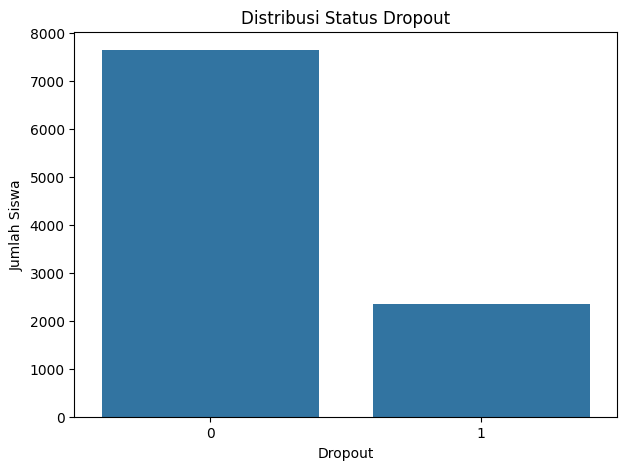

Jumlah:
Dropout
0    7646
1    2354
Name: count, dtype: int64

Persentase (%):
Dropout
0    76.46
1    23.54
Name: proportion, dtype: float64


In [16]:
dropout_counts = df["Dropout"].value_counts().sort_index()
dropout_percentage = (df["Dropout"].value_counts(normalize=True).sort_index() * 100).round(2)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Dropout")
plt.title("Distribusi Status Dropout")
plt.xlabel("Dropout")
plt.ylabel("Jumlah Siswa")
plt.show()

print("Jumlah:")
print(dropout_counts)
print("\nPersentase (%):")
print(dropout_percentage)

### Insight

Distribusi target menunjukkan bahwa terdapat **7.646 siswa (76,46%)** dengan `Dropout = 0` dan **2.354 siswa (23,54%)** dengan `Dropout = 1`.

Distribusi tersebut menunjukkan bahwa kelas `Not Dropout` memiliki jumlah observasi yang lebih besar dibandingkan kelas `Dropout`. Kondisi ini perlu diperhatikan pada tahap pemodelan karena kesalahan dalam mendeteksi siswa yang benar-benar dropout perlu menjadi bagian dari pertimbangan evaluasi model.

Oleh karena itu, evaluasi model tidak hanya menggunakan accuracy, tetapi juga mempertimbangkan **precision, recall, F1-score, dan ROC-AUC**.

## **5.2 Correlation Matrix**

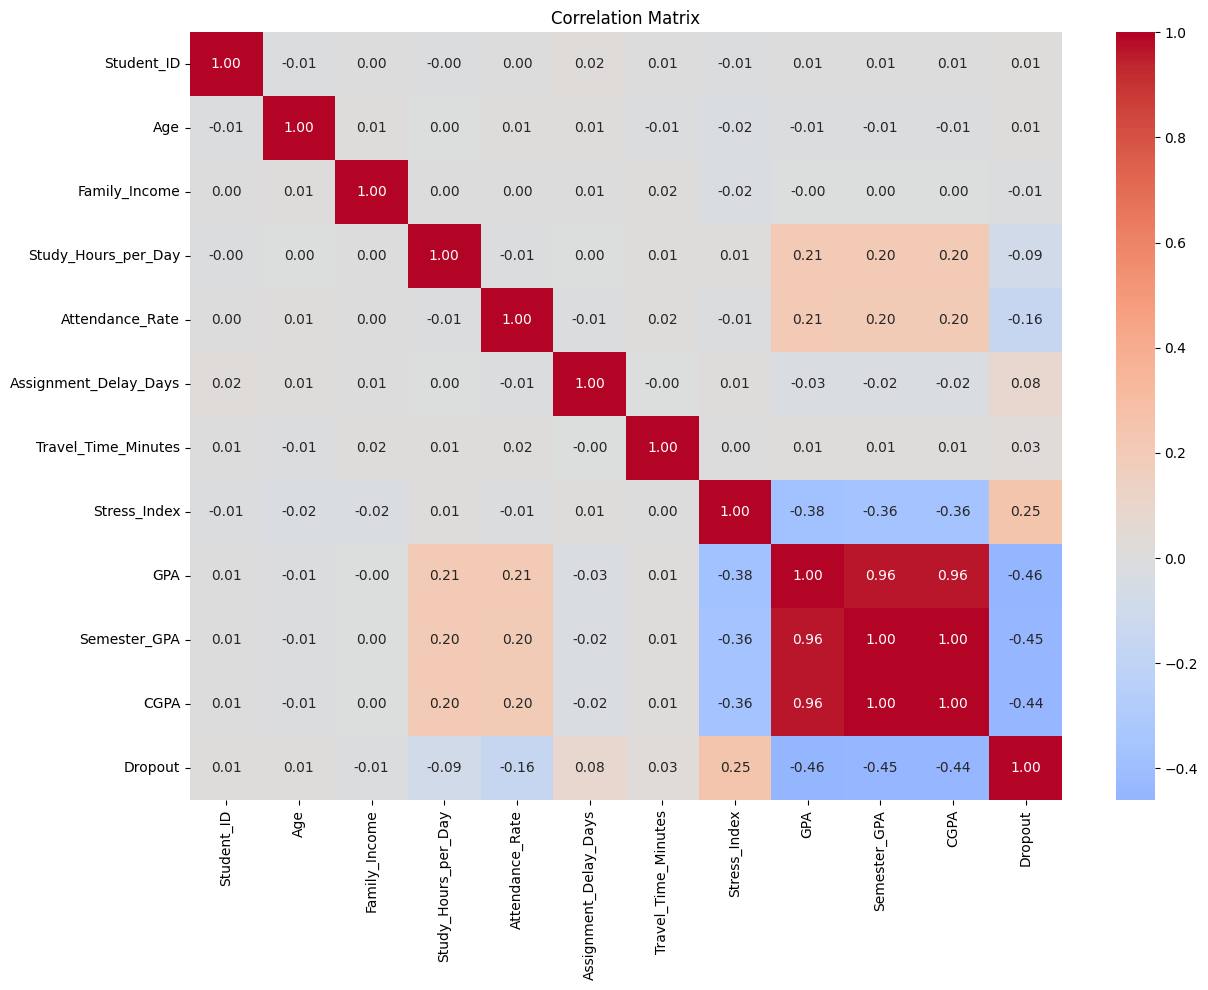

In [17]:
correlation_cols = df.select_dtypes(include=np.number).columns

correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Insight

Correlation matrix digunakan untuk melihat pola hubungan linear antarvariabel numerik.

Terlihat bahwa `GPA`, `Semester_GPA`, dan `CGPA` memiliki hubungan yang sangat kuat satu sama lain. Hal ini menunjukkan adanya informasi yang relatif redundant pada ketiga variabel tersebut.

Temuan ini menjadi salah satu pertimbangan pada tahap **Feature Selection**, terutama ketika menentukan fitur yang akan digunakan pada Lightweight Model.

## **5.3 Correlation dengan Dropout**

In [18]:
dropout_correlation = (
    df.select_dtypes(include=np.number)
      .corr()["Dropout"]
      .drop("Dropout")
      .sort_values(key=abs, ascending=False)
)

dropout_correlation.to_frame("correlation_with_dropout")

,correlation_with_dropout
GPA,-0.460352
Semester_GPA,-0.445396
CGPA,-0.444807
Stress_Index,0.249361
Attendance_Rate,-0.163539
Study_Hours_per_Day,-0.087163
Assignment_Delay_Days,0.082327
Travel_Time_Minutes,0.028080
Family_Income,-0.010324
Age,0.007585


### Insight

Hasil korelasi menunjukkan bahwa `GPA` memiliki korelasi negatif paling kuat dengan `Dropout` dibandingkan variabel numerik lainnya, yaitu sebesar **-0,46**.

`Semester_GPA` dan `CGPA` juga menunjukkan korelasi negatif yang relatif kuat, sedangkan `Stress_Index` menunjukkan korelasi positif sebesar **0,25**.

Temuan ini menunjukkan adanya pola hubungan linear antara beberapa indikator siswa dengan status dropout. Namun, hasil korelasi digunakan sebagai analisis eksploratif dan **tidak menunjukkan hubungan sebab-akibat**.

## **5.4 Hubungan Faktor Akademik dengan Dropout**

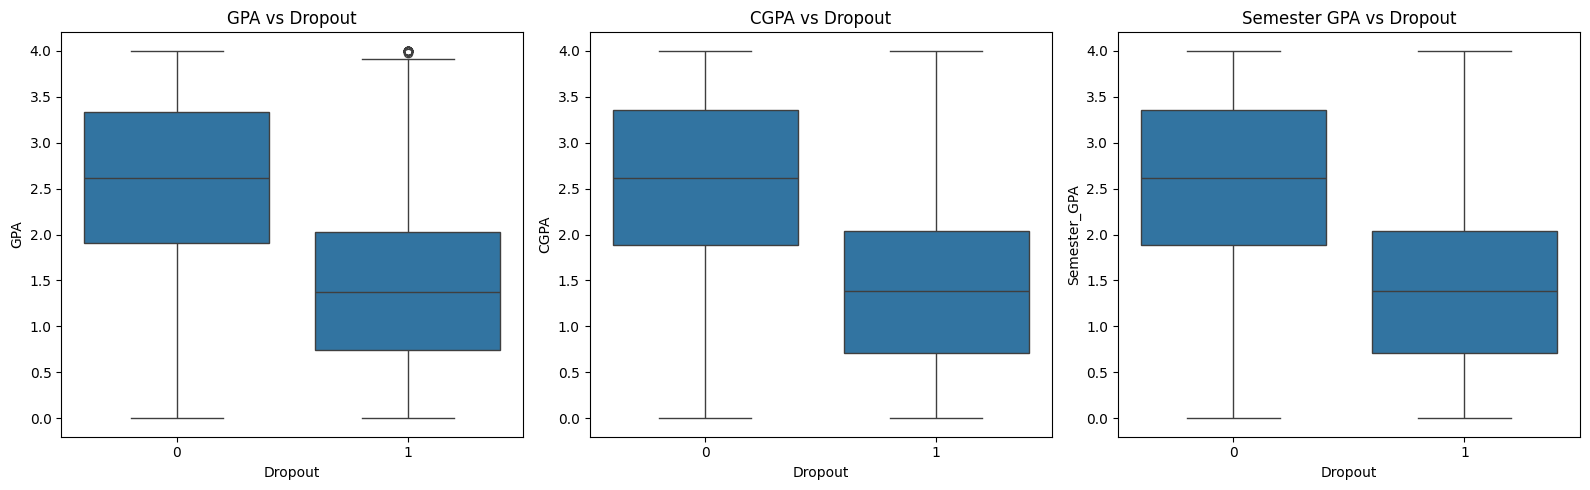

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Dropout", y="GPA", ax=axes[0])
axes[0].set_title("GPA vs Dropout")

sns.boxplot(data=df, x="Dropout", y="CGPA", ax=axes[1])
axes[1].set_title("CGPA vs Dropout")

sns.boxplot(data=df, x="Dropout", y="Semester_GPA", ax=axes[2])
axes[2].set_title("Semester GPA vs Dropout")

plt.tight_layout()
plt.show()

### Insight

Siswa dengan status `Dropout = 1` cenderung memiliki GPA, Semester GPA, dan CGPA yang lebih rendah dibandingkan siswa dengan `Dropout = 0`. Ketiga variabel juga memiliki korelasi yang sangat tinggi satu sama lain, sehingga terdapat indikasi informasi yang redundant. Namun, fitur belum dihapus pada tahap EDA dan akan dievaluasi lebih lanjut melalui proses pemodelan.

## **5.5 Hubungan Kehadiran dan Kebiasaan Belajar**

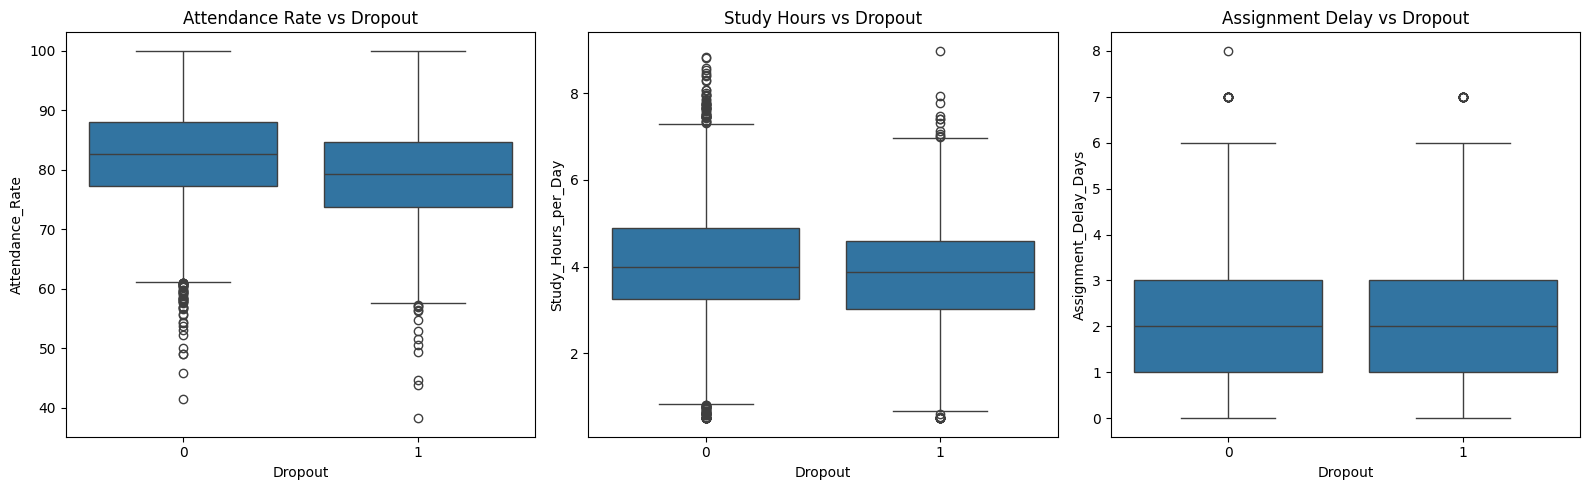

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="Dropout", y="Attendance_Rate", ax=axes[0])
axes[0].set_title("Attendance Rate vs Dropout")

sns.boxplot(data=df, x="Dropout", y="Study_Hours_per_Day", ax=axes[1])
axes[1].set_title("Study Hours vs Dropout")

sns.boxplot(data=df, x="Dropout", y="Assignment_Delay_Days", ax=axes[2])
axes[2].set_title("Assignment Delay vs Dropout")

plt.tight_layout()
plt.show()

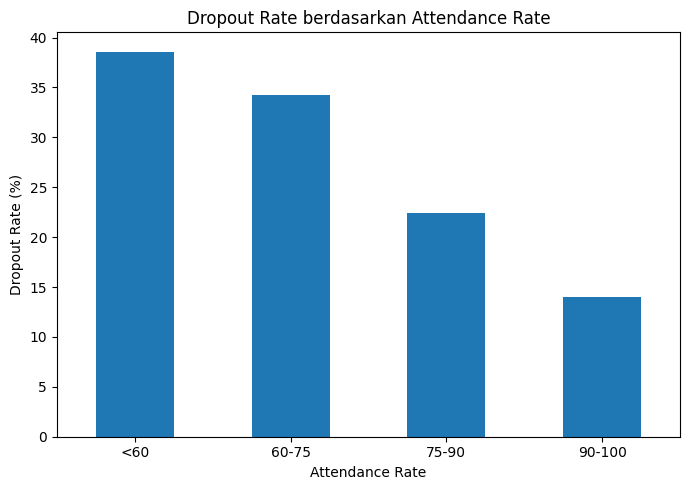

,Dropout Rate (%)
Attendance_Group,
<60,38.60
60-75,34.24
75-90,22.47
90-100,13.96


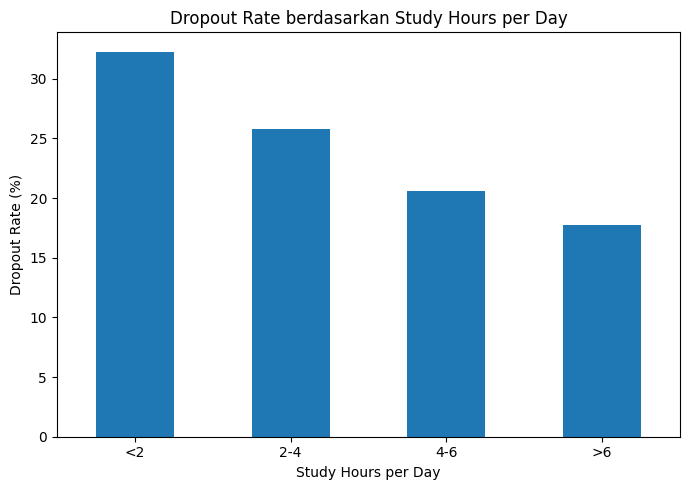

,Dropout Rate (%)
Study_Hours_Group,
<2,32.27
2-4,25.75
4-6,20.62
>6,17.76


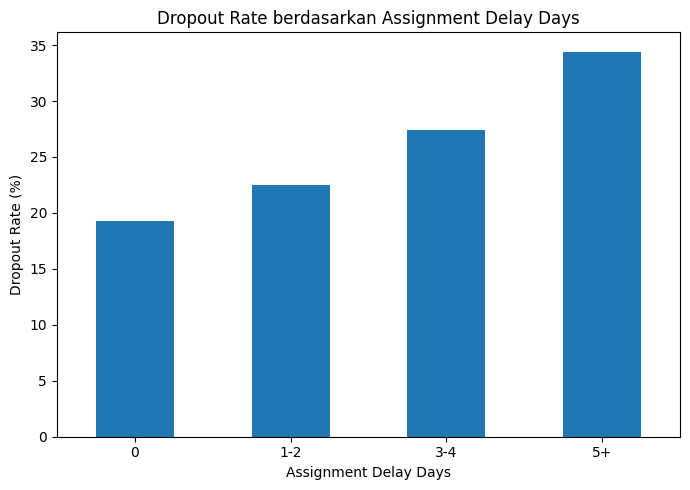

,Dropout Rate (%)
Delay_Group,
0,19.25
1-2,22.50
3-4,27.42
5+,34.42


In [21]:
# Membuat kelompok untuk melihat dropout rate
df_eda = df.copy()

df_eda["Attendance_Group"] = pd.cut(
    df_eda["Attendance_Rate"],
    bins=[0, 60, 75, 90, 100],
    labels=["<60", "60-75", "75-90", "90-100"],
    include_lowest=True
)

df_eda["Study_Hours_Group"] = pd.cut(
    df_eda["Study_Hours_per_Day"],
    bins=[0, 2, 4, 6, 10],
    labels=["<2", "2-4", "4-6", ">6"],
    include_lowest=True
)

df_eda["Delay_Group"] = pd.cut(
    df_eda["Assignment_Delay_Days"],
    bins=[-1, 0, 2, 4, 8],
    labels=["0", "1-2", "3-4", "5+"],
    include_lowest=True
)

groups = {
    "Attendance Rate": "Attendance_Group",
    "Study Hours per Day": "Study_Hours_Group",
    "Assignment Delay Days": "Delay_Group"
}

for title, col in groups.items():

    dropout_rate = (
        df_eda.groupby(col, observed=False)["Dropout"]
        .mean()
        .mul(100)
    )

    plt.figure(figsize=(7, 5))
    dropout_rate.plot(kind="bar")

    plt.title(f"Dropout Rate berdasarkan {title}")
    plt.xlabel(title)
    plt.ylabel("Dropout Rate (%)")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    display(
        dropout_rate.round(2).to_frame("Dropout Rate (%)")
    )

### Insight

Analisis berbasis kelompok menunjukkan adanya pola perubahan dropout rate pada beberapa indikator.

Pada `Attendance_Rate`, dropout rate menurun dari **38,60%** pada kelompok kehadiran di bawah 60% menjadi **13,96%** pada kelompok kehadiran 90–100%.

Pada `Study_Hours_per_Day`, dropout rate menurun dari **32,27%** pada siswa dengan waktu belajar kurang dari 2 jam per hari menjadi **17,76%** pada siswa dengan waktu belajar lebih dari 6 jam.

Sebaliknya, pada `Assignment_Delay_Days`, dropout rate meningkat dari **19,25%** pada siswa tanpa keterlambatan tugas menjadi **34,42%** pada kelompok dengan keterlambatan 5 hari atau lebih.

Pola tersebut menunjukkan adanya perbedaan dropout rate pada kelompok indikator yang dianalisis. Temuan ini bersifat deskriptif dan tidak dapat diartikan sebagai hubungan sebab-akibat.

## **5.6 Faktor Pendukung Siswa**

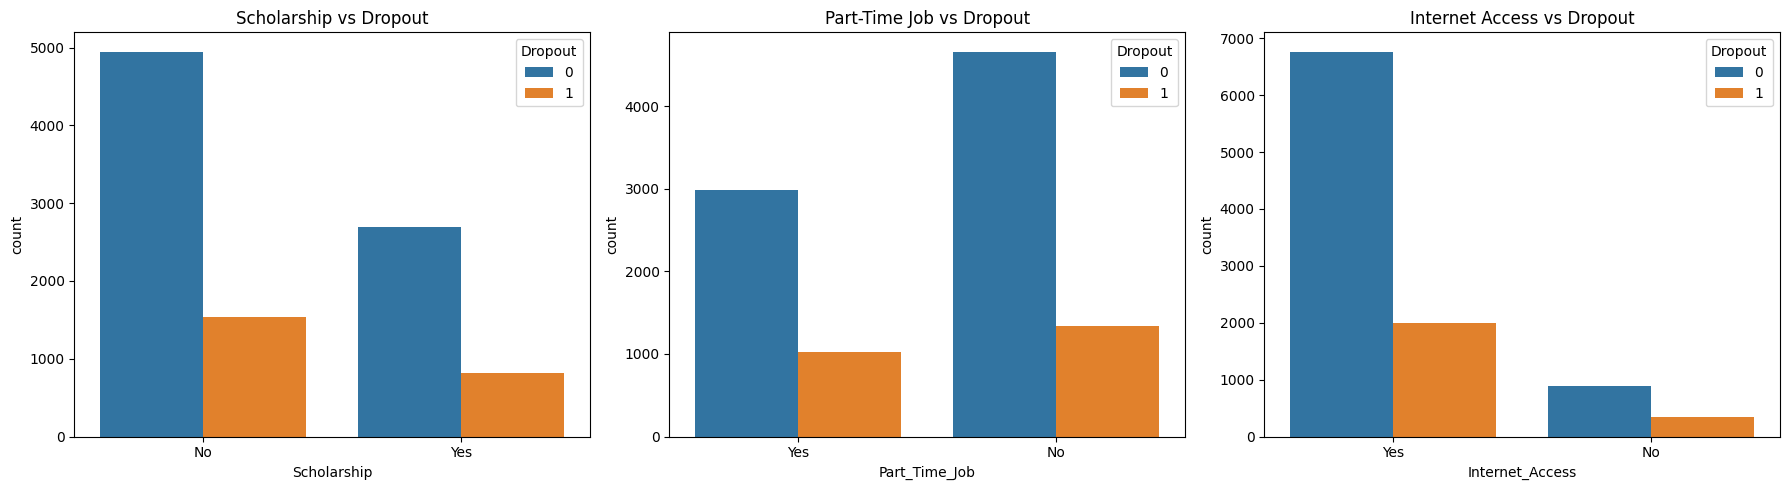

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Scholarship", hue="Dropout", ax=axes[0])
axes[0].set_title("Scholarship vs Dropout")

sns.countplot(data=df, x="Part_Time_Job", hue="Dropout", ax=axes[1])
axes[1].set_title("Part-Time Job vs Dropout")

sns.countplot(data=df, x="Internet_Access", hue="Dropout", ax=axes[2])
axes[2].set_title("Internet Access vs Dropout")

plt.tight_layout()
plt.show()

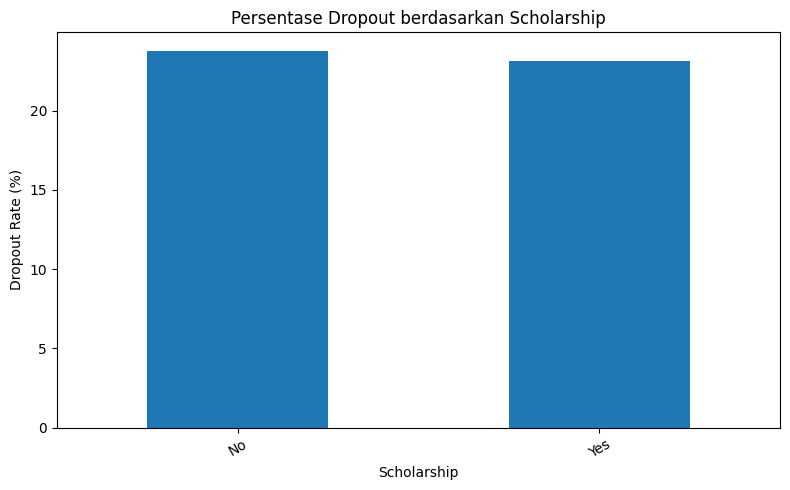

,Dropout Rate (%)
Scholarship,
No,23.75
Yes,23.16


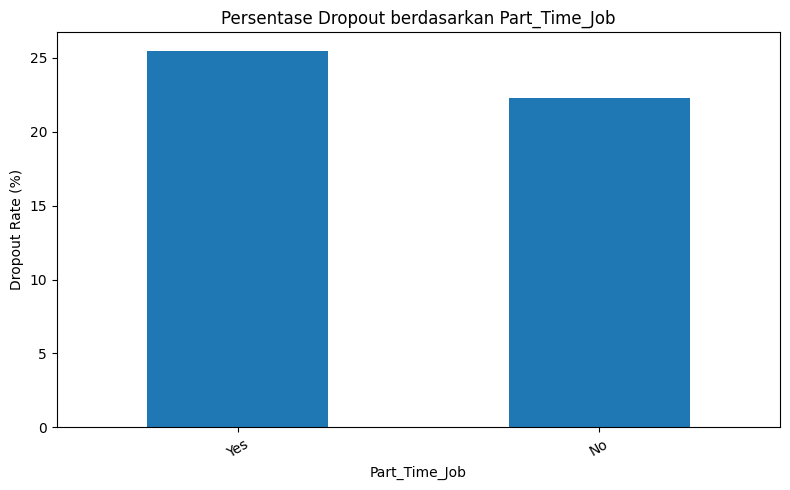

,Dropout Rate (%)
Part_Time_Job,
Yes,25.45
No,22.26


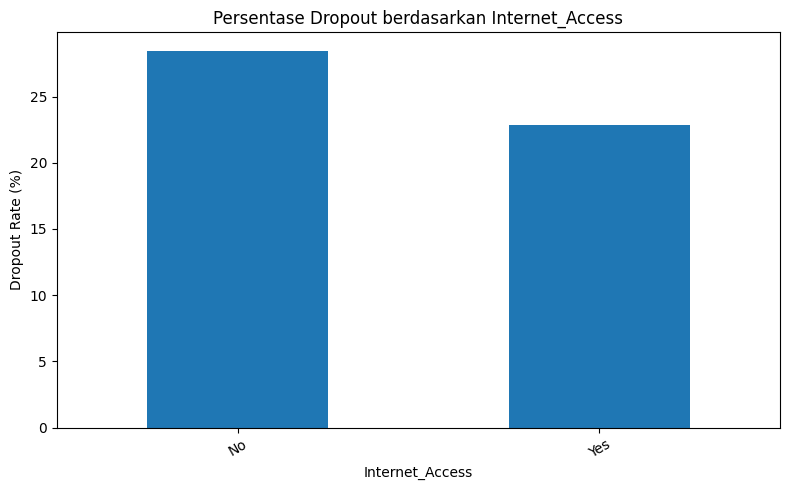

,Dropout Rate (%)
Internet_Access,
No,28.43
Yes,22.85


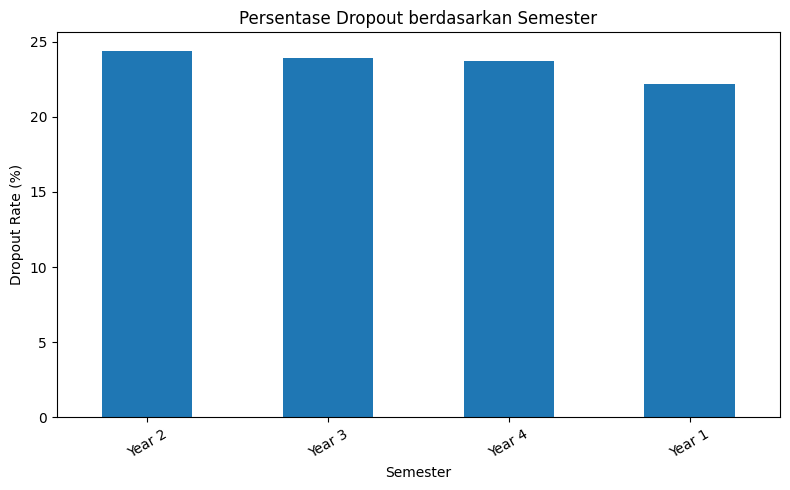

,Dropout Rate (%)
Semester,
Year 2,24.40
Year 3,23.88
Year 4,23.70
Year 1,22.16


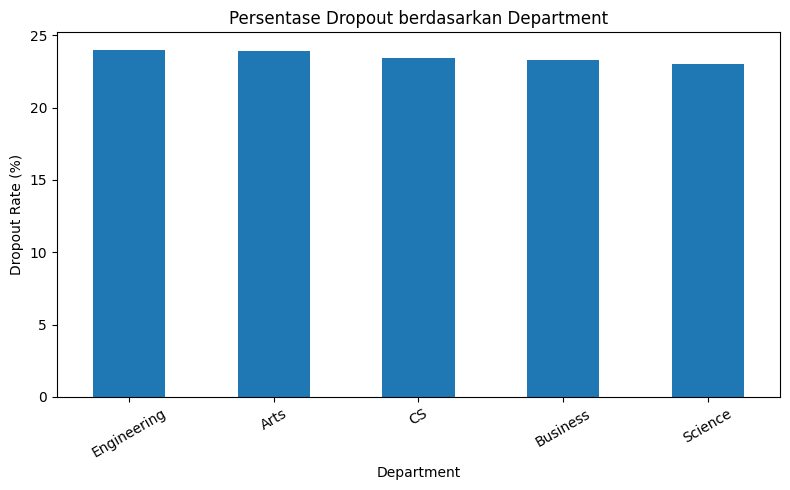

,Dropout Rate (%)
Department,
Engineering,24.01
Arts,23.94
CS,23.40
Business,23.33
Science,23.05


In [23]:
# Analisis dropout rate berdasarkan faktor pendukung siswa

support_features = [
    "Scholarship",
    "Part_Time_Job",
    "Internet_Access",
    "Semester",
    "Department"
]

for col in support_features:

    dropout_rate = (
        df.groupby(col)["Dropout"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))

    dropout_rate.plot(kind="bar")

    plt.title(f"Persentase Dropout berdasarkan {col}")
    plt.xlabel(col)
    plt.ylabel("Dropout Rate (%)")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    display(
        dropout_rate
        .round(2)
        .to_frame("Dropout Rate (%)")
    )

### Insight

Analisis menunjukkan adanya perbedaan dropout rate pada beberapa kelompok
siswa. Pada variabel Part_Time_Job, kelompok siswa yang memiliki pekerjaan
paruh waktu memiliki dropout rate sebesar 25.45%, sedangkan kelompok tanpa
pekerjaan paruh waktu sebesar 22.26%.

Berdasarkan semester, dropout rate berada pada rentang 22.16%–24.40%,
dengan Year 2 memiliki dropout rate tertinggi sebesar 24.40%.

Berdasarkan department, dropout rate berada pada rentang 23.05%–24.01%.
Engineering memiliki dropout rate sebesar 24.01%, sedangkan Science
sebesar 23.05%.

Perbedaan pada Scholarship dan Internet_Access juga digunakan sebagai
informasi deskriptif untuk memahami karakteristik kelompok siswa.

Analisis ini bersifat deskriptif dan tidak digunakan untuk menyimpulkan
hubungan sebab-akibat.

## **5.7 Feature Selection**

Feature selection digunakan untuk melihat variabel mana yang paling informatif untuk prediksi dropout. Karena `GPA`, `Semester_GPA`, dan `CGPA` memiliki informasi yang sangat redundant, hasil feature importance juga akan digunakan sebagai dasar untuk membuat **Lightweight Model** dengan input yang lebih sedikit.

Feature importance dihitung menggunakan data training agar data testing tidak digunakan dalam proses seleksi.

In [24]:
# Menyiapkan data untuk feature importance

X_fs = df.drop(columns=["Dropout", "Student_ID"])
y_fs = df["Dropout"]

X_fs_train, X_fs_test, y_fs_train, y_fs_test = train_test_split(
    X_fs,
    y_fs,
    test_size=0.2,
    random_state=42,
    stratify=y_fs
)

categorical_fs = X_fs_train.select_dtypes(include="object").columns.tolist()
numeric_fs = X_fs_train.select_dtypes(include=np.number).columns.tolist()

preprocessor_fs = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_fs),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_fs)
])

X_fs_train_transformed = preprocessor_fs.fit_transform(X_fs_train)
feature_names_fs = preprocessor_fs.get_feature_names_out()

print("Fitur asli:", X_fs_train.shape[1])
print("Fitur setelah One-Hot Encoding:", len(feature_names_fs))

Fitur asli: 17
Fitur setelah One-Hot Encoding: 31


In [25]:
# Random Forest untuk feature importance

rf_fs = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_fs.fit(X_fs_train_transformed, y_fs_train)

feature_importance_df = pd.DataFrame({
    "encoded_feature": feature_names_fs,
    "importance": rf_fs.feature_importances_
})

feature_importance_df.head(10)

,encoded_feature,importance
0,numeric__Age,0.057411
1,numeric__Family_Income,0.044678
2,numeric__Study_Hours_per_Day,0.064521
3,numeric__Attendance_Rate,0.074941
4,numeric__Assignment_Delay_Days,0.030817
5,numeric__Travel_Time_Minutes,0.063500
6,numeric__Stress_Index,0.076638
7,numeric__GPA,0.157462
8,numeric__Semester_GPA,0.140275
9,numeric__CGPA,0.127439


In [26]:
# Menggabungkan importance kembali ke variabel asli

def get_original_feature(encoded_name):
    for feature in numeric_fs:
        if encoded_name == f"numeric__{feature}":
            return feature

    for feature in categorical_fs:
        prefix = f"categorical__{feature}_"
        if encoded_name.startswith(prefix):
            return feature

    return encoded_name

feature_importance_df["original_feature"] = (
    feature_importance_df["encoded_feature"].apply(get_original_feature)
)

original_importance_df = (
    feature_importance_df
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

original_importance_df

,original_feature,importance
6,GPA,0.157462
13,Semester_GPA,0.140275
3,CGPA,0.127439
14,Stress_Index,0.076638
2,Attendance_Rate,0.074941
15,Study_Hours_per_Day,0.064521
16,Travel_Time_Minutes,0.063500
0,Age,0.057411
5,Family_Income,0.044678
4,Department,0.040315


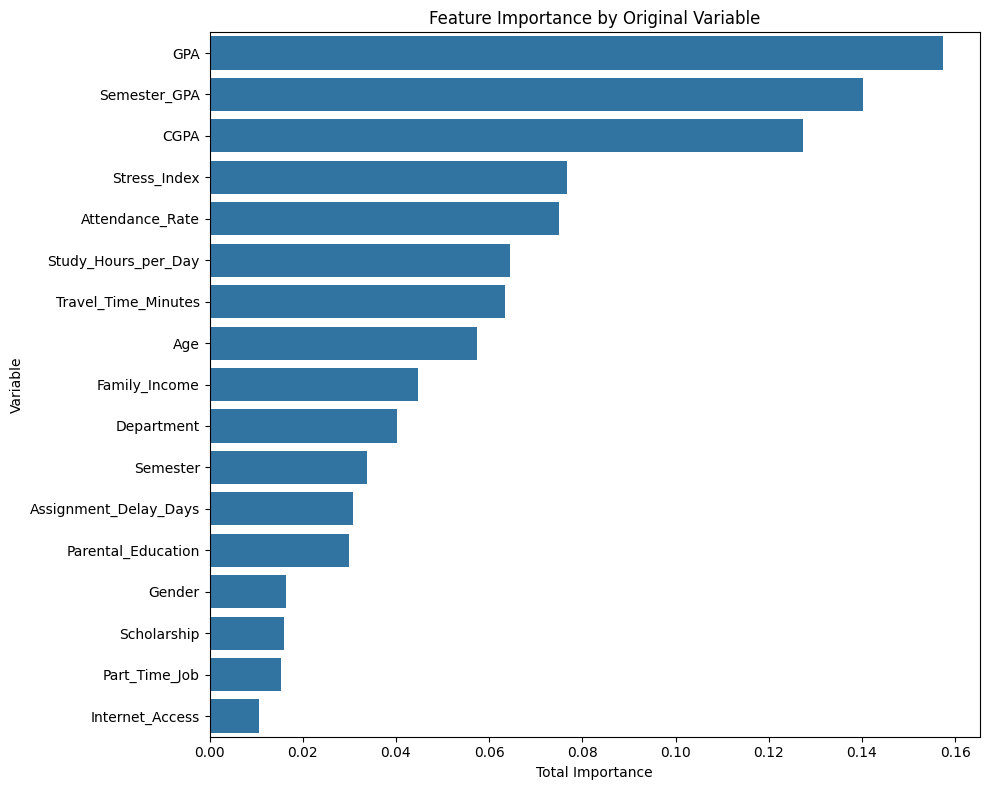

In [27]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=original_importance_df,
    x="importance",
    y="original_feature"
)

plt.title("Feature Importance by Original Variable")
plt.xlabel("Total Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Insight

Hasil feature importance menunjukkan bahwa `GPA`, `Semester_GPA`, dan `CGPA` memiliki importance tertinggi dibandingkan variabel lainnya. Ketiga fitur tersebut juga memiliki informasi yang saling redundant, sehingga tidak seluruhnya digunakan pada Lightweight Model.

Selain ketiga fitur akademik tersebut, `Stress_Index`, `Attendance_Rate`, `Study_Hours_per_Day`, dan `Travel_Time_Minutes` juga menunjukkan importance yang relatif tinggi. `Assignment_Delay_Days` tetap dipertahankan karena mewakili aspek keterlambatan akademik.

Berdasarkan hasil feature importance dan kebutuhan integrasi Fullstack → ML, dipilih enam fitur untuk Lightweight Model, yaitu:

- `GPA`
- `Stress_Index`
- `Attendance_Rate`
- `Study_Hours_per_Day`
- `Travel_Time_Minutes`
- `Assignment_Delay_Days`

Pemilihan enam fitur tersebut dilakukan untuk mengurangi jumlah input yang diperlukan aplikasi, sekaligus tetap mempertahankan beberapa indikator utama yang digunakan untuk memprediksi risiko dropout.

### **Lightweight Model Feature Set**

Untuk kebutuhan integrasi Fullstack → ML, dibuat model kedua yang hanya membutuhkan input utama yang mudah tersedia dan tidak memasukkan tiga variabel akademik yang redundant sekaligus.

`GPA` digunakan sebagai satu representasi performa akademik. `Semester_GPA` dan `CGPA` tidak dimasukkan ke Lightweight Model.

Fitur Lightweight Model:

- `GPA`
- `Stress_Index`
- `Attendance_Rate`
- `Study_Hours_per_Day`
- `Travel_Time_Minutes`
- `Assignment_Delay_Days`

# **6. Data Preparation**

Pada tahap Data Preparation, data disiapkan untuk proses pemodelan dengan membandingkan dua konfigurasi fitur:

- **Full Features:** seluruh fitur prediktor kecuali `Student_ID`.
- **Lightweight Features:** enam fitur utama yang dipilih untuk mengurangi jumlah input yang diperlukan aplikasi saat berkomunikasi dengan model Machine Learning.

Dataset kemudian dibagi menjadi data training dan testing dengan rasio **80:20** menggunakan stratifikasi berdasarkan target `Dropout`. Data testing hanya digunakan untuk evaluasi akhir, sedangkan proses preprocessing dan pengembangan model dilakukan menggunakan data training.

In [28]:
target_col = "Dropout"
id_col = "Student_ID"

full_features = [col for col in df.columns if col not in [target_col, id_col]]

lightweight_features = [
    "GPA",
    "Stress_Index",
    "Attendance_Rate",
    "Study_Hours_per_Day",
    "Travel_Time_Minutes",
    "Assignment_Delay_Days"
]

X = df.drop(columns=[target_col, id_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Full features:", len(full_features))
print("Lightweight features:", len(lightweight_features))
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Full features: 17
Lightweight features: 6
Training: (8000, 17)
Testing : (2000, 17)


### Insight

Dataset berhasil dipisahkan menjadi **8.000 data training** dan **2.000 data testing** dengan rasio 80:20.

Konfigurasi **Full Features** menggunakan 17 fitur prediktor, sedangkan **Lightweight Features** menggunakan 6 fitur utama. Setelah preprocessing, Full Features menghasilkan 31 fitur hasil transformasi karena adanya One-Hot Encoding pada variabel kategorikal, sedangkan Lightweight Features tetap memiliki 6 fitur karena seluruh inputnya berupa variabel numerik.

Perbedaan jumlah fitur ini digunakan untuk membandingkan kebutuhan model dengan data lengkap dan kebutuhan model yang lebih sederhana untuk integrasi aplikasi.

In [29]:
def build_preprocessor(X_data):
    categorical_cols = X_data.select_dtypes(include="object").columns.tolist()
    numeric_cols = X_data.select_dtypes(include=np.number).columns.tolist()

    return ColumnTransformer([
        ("numeric", SimpleImputer(strategy="median"), numeric_cols),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ])

preprocessor_full = build_preprocessor(X_train[full_features])
preprocessor_lightweight = build_preprocessor(X_train[lightweight_features])

X_train_full = preprocessor_full.fit_transform(X_train[full_features])
X_test_full = preprocessor_full.transform(X_test[full_features])

X_train_lightweight = preprocessor_lightweight.fit_transform(
    X_train[lightweight_features]
)
X_test_lightweight = preprocessor_lightweight.transform(
    X_test[lightweight_features]
)

print("Full encoded:", X_train_full.shape)
print("Lightweight encoded:", X_train_lightweight.shape)

Full encoded: (8000, 31)
Lightweight encoded: (8000, 6)


## **6.1 Ringkasan Data Preparation**

Data dibagi menjadi dua konfigurasi fitur, yaitu Full Features dan
Lightweight Features. Full Features menggunakan seluruh variabel prediktor
kecuali `Student_ID`, sedangkan Lightweight Features menggunakan enam
variabel utama yang dipilih untuk mendukung kebutuhan integrasi Fullstack
ke Machine Learning.

Dataset dibagi menggunakan rasio 80:20 dengan stratifikasi berdasarkan
target `Dropout`. Data training digunakan untuk proses preprocessing dan
pengembangan model, sedangkan data testing disimpan untuk evaluasi akhir.

Preprocessing numerik menggunakan median imputation, sedangkan fitur
kategorikal menggunakan most-frequent imputation dan One-Hot Encoding.
Preprocessor di-fit menggunakan data training dan kemudian diterapkan
pada data testing untuk menjaga pemisahan data selama proses modeling.

### Insight

Tahap Data Preparation menghasilkan dua konfigurasi data yang dapat digunakan untuk membandingkan kebutuhan model secara langsung.

**Full Features** mempertahankan seluruh informasi prediktor yang tersedia, sedangkan **Lightweight Features** menggunakan enam fitur utama yang telah dipilih pada tahap Feature Selection. Dengan pendekatan ini, proses pemodelan dapat mengevaluasi trade-off antara penggunaan fitur yang lebih lengkap dan kebutuhan input yang lebih sederhana untuk integrasi aplikasi.

# **7. Model Development**

Model utama dan Lightweight Model dibandingkan menggunakan model klasifikasi yang sama. Evaluasi dilakukan dengan **Stratified 5-Fold Cross Validation pada training set**.

Metrik utama untuk kasus dropout adalah **Recall dan F1-score**, karena sistem perlu meminimalkan siswa dropout yang tidak terdeteksi.

In [30]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

def evaluate_feature_set(X_data, y_data, feature_set_name):
    rows = []

    for model_name, model in models.items():
        scores = cross_validate(
            model,
            X_data,
            y_data,
            cv=cv,
            scoring=scoring,
            n_jobs=-1
        )

        rows.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            "Accuracy": scores["test_accuracy"].mean(),
            "Precision": scores["test_precision"].mean(),
            "Recall": scores["test_recall"].mean(),
            "F1": scores["test_f1"].mean(),
            "ROC-AUC": scores["test_roc_auc"].mean()
        })

    return pd.DataFrame(rows)

cv_full_results = evaluate_feature_set(
    X_train_full, y_train, "Full Features"
)

cv_lightweight_results = evaluate_feature_set(
    X_train_lightweight, y_train, "Lightweight Features"
)

cv_results = pd.concat(
    [cv_full_results, cv_lightweight_results],
    ignore_index=True
)

cv_results.sort_values(
    ["F1", "Recall", "ROC-AUC"],
    ascending=False
)

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,Lightweight Features,Logistic Regression,0.742500,0.470374,0.746674,0.577029,0.820343
0,Full Features,Logistic Regression,0.739625,0.466583,0.747198,0.574269,0.818770
7,Lightweight Features,Gradient Boosting,0.802250,0.628123,0.394579,0.484371,0.811946
3,Full Features,Gradient Boosting,0.802625,0.631372,0.390317,0.481939,0.811958
2,Full Features,Random Forest,0.804000,0.653158,0.357409,0.461762,0.808089
6,Lightweight Features,Random Forest,0.797875,0.618963,0.367505,0.461179,0.800254
1,Full Features,Decision Tree,0.728250,0.422495,0.420063,0.421013,0.621588
5,Lightweight Features,Decision Tree,0.726625,0.419463,0.420604,0.419885,0.620715


## **7.1 Full Features vs Lightweight Features**

Perbandingan ini menjawab dua kebutuhan:

- **Full Model:** memaksimalkan performa dengan data yang tersedia.
- **Lightweight Model:** mengurangi jumlah input yang harus dikirim dari Fullstack ke ML.

Lightweight Model tidak dimaksudkan untuk menggantikan Full Model secara otomatis. Model ini menjadi opsi ketika aplikasi hanya memiliki enam input utama.

In [31]:
comparison_table = cv_results.pivot(
    index="Model",
    columns="Feature Set",
    values=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
)

comparison_table

Accuracy                          Precision  \
Feature Set         Full Features Lightweight Features Full Features   
Model                                                                  
Decision Tree            0.728250             0.726625      0.422495   
Gradient Boosting        0.802625             0.802250      0.631372   
Logistic Regression      0.739625             0.742500      0.466583   
Random Forest            0.804000             0.797875      0.653158   

                                                Recall                       \
Feature Set         Lightweight Features Full Features Lightweight Features   
Model                                                                         
Decision Tree                   0.419463      0.420063             0.420604   
Gradient Boosting               0.628123      0.390317             0.394579   
Logistic Regression             0.470374      0.747198             0.746674   
Random Forest                   0.618963      0.357409             0.367505   

                               F1                            ROC-AUC  \
Feature Set         Full Features Lightweight Features Full Features   
Model                                                                  
Decision Tree            0.421013             0.419885      0.621588   
Gradient Boosting        0.481939             0.484371      0.811958   
Logistic Regression      0.574269             0.577029      0.818770   
Random Forest            0.461762             0.461179      0.808089   

                                          
Feature Set         Lightweight Features  
Model                                     
Decision Tree                   0.620715  
Gradient Boosting               0.811946  
Logistic Regression             0.820343  
Random Forest                   0.800254

### Insight

Hasil Stratified 5-Fold Cross Validation menunjukkan bahwa konfigurasi Lightweight Features memberikan performa yang sangat dekat dengan Full Features pada Logistic Regression.

Pada Logistic Regression, Lightweight Features menghasilkan Accuracy **0,7425**, Recall **0,7467**, F1-score **0,5770**, dan ROC-AUC **0,8203**. Sementara itu, Full Features menghasilkan Accuracy **0,7396**, Recall **0,7472**, F1-score **0,5743**, dan ROC-AUC **0,8188**.

Perbedaan performa tersebut relatif kecil, sehingga enam fitur pada Lightweight Features tetap dapat digunakan untuk kebutuhan integrasi aplikasi tanpa menggunakan seluruh fitur prediktor.

In [32]:
# Ringkasan model terbaik pada masing-masing feature set

best_full = (
    cv_full_results
    .sort_values(["F1", "Recall", "ROC-AUC"], ascending=False)
    .iloc[0]
)

best_lightweight = (
    cv_lightweight_results
    .sort_values(["F1", "Recall", "ROC-AUC"], ascending=False)
    .iloc[0]
)

summary_feature_sets = pd.DataFrame([
    best_full,
    best_lightweight
])

summary_feature_sets

,Feature Set,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Full Features,Logistic Regression,0.739625,0.466583,0.747198,0.574269,0.818770
0,Lightweight Features,Logistic Regression,0.742500,0.470374,0.746674,0.577029,0.820343


## **7.2 Pemilihan Model Utama**

Hasil **Stratified 5-Fold Cross Validation** digunakan untuk membandingkan
performa model pada **Full Features** dan **Lightweight Features**.

Dalam pengembangan EduPulse, **Lightweight Features** dipilih sebagai
konfigurasi input utama karena aplikasi membutuhkan jumlah input yang
lebih sederhana untuk proses integrasi **Fullstack → Machine Learning**.
Konfigurasi ini menggunakan enam fitur, yaitu `GPA`, `Stress_Index`,
`Attendance_Rate`, `Study_Hours_per_Day`, `Travel_Time_Minutes`, dan
`Assignment_Delay_Days`.

Pemilihan model tidak hanya mempertimbangkan Accuracy, tetapi juga
disesuaikan dengan tujuan EduPulse sebagai **early warning system**.
Pada kasus dropout, kesalahan ketika siswa yang sebenarnya dropout tidak
terdeteksi perlu diminimalkan. Oleh karena itu, **Recall** pada kelas
Dropout menjadi metrik penting, sedangkan **F1-score** digunakan sebagai
metrik pendukung untuk mempertimbangkan keseimbangan antara Recall dan
Precision.

Berdasarkan hasil pengujian pada Lightweight Features, **Logistic
Regression** menghasilkan Recall sebesar **0.7467**, F1-score sebesar
**0.5770**, dan ROC-AUC sebesar **0.8203**. Sementara itu, Gradient
Boosting memiliki Accuracy yang lebih tinggi, yaitu **0.8023**, tetapi
Recall-nya hanya **0.3946**.

Dengan mempertimbangkan kebutuhan integrasi enam input dan tujuan utama
EduPulse sebagai early warning system, **Lightweight Features +
Logistic Regression dipilih sebagai model utama**.

### Insight

Hasil perbandingan menunjukkan bahwa pemilihan model tidak didasarkan pada Accuracy saja. Pada Lightweight Features, Gradient Boosting memiliki Accuracy sebesar **0,8023**, tetapi Recall hanya **0,3946**. Sebaliknya, Logistic Regression memiliki Accuracy sebesar **0,7425** dengan Recall **0,7467** dan F1-score **0,5770**.

Karena EduPulse digunakan sebagai **early warning system**, kemampuan mendeteksi siswa yang termasuk kelas `Dropout` menjadi pertimbangan penting dalam pemilihan model. Oleh karena itu, kombinasi **Lightweight Features + Logistic Regression** digunakan sebagai konfigurasi model utama.

In [33]:
# Benchmark performa berdasarkan Accuracy

best_full_accuracy = (
    cv_full_results
    .sort_values(
        ["Accuracy", "F1", "ROC-AUC", "Recall"],
        ascending=False
    )
    .iloc[0]
)

best_lightweight_accuracy = (
    cv_lightweight_results
    .sort_values(
        ["Accuracy", "F1", "ROC-AUC", "Recall"],
        ascending=False
    )
    .iloc[0]
)

print("=== ACCURACY BENCHMARK - FULL FEATURES ===")
print("Model       :", best_full_accuracy["Model"])
print("Accuracy    :", round(best_full_accuracy["Accuracy"], 4))
print("Precision   :", round(best_full_accuracy["Precision"], 4))
print("Recall      :", round(best_full_accuracy["Recall"], 4))
print("F1          :", round(best_full_accuracy["F1"], 4))
print("ROC-AUC     :", round(best_full_accuracy["ROC-AUC"], 4))

print("\n=== ACCURACY BENCHMARK - LIGHTWEIGHT FEATURES ===")
print("Model       :", best_lightweight_accuracy["Model"])
print("Accuracy    :", round(best_lightweight_accuracy["Accuracy"], 4))
print("Precision   :", round(best_lightweight_accuracy["Precision"], 4))
print("Recall      :", round(best_lightweight_accuracy["Recall"], 4))
print("F1          :", round(best_lightweight_accuracy["F1"], 4))
print("ROC-AUC     :", round(best_lightweight_accuracy["ROC-AUC"], 4))

print("\n=== FINAL MODEL ===")
print("Model       : Logistic Regression")
print("Feature Set : Lightweight Features")
print("Inputs      :", len(lightweight_features))

=== ACCURACY BENCHMARK - FULL FEATURES ===
Model       : Random Forest
Accuracy    : 0.804
Precision   : 0.6532
Recall      : 0.3574
F1          : 0.4618
ROC-AUC     : 0.8081

=== ACCURACY BENCHMARK - LIGHTWEIGHT FEATURES ===
Model       : Gradient Boosting
Accuracy    : 0.8022
Precision   : 0.6281
Recall      : 0.3946
F1          : 0.4844
ROC-AUC     : 0.8119

=== FINAL MODEL ===
Model       : Logistic Regression
Feature Set : Lightweight Features
Inputs      : 6


## **7.3 Final Model Configuration**

Konfigurasi final model ditetapkan berdasarkan hasil perbandingan pada tahap sebelumnya.

Model yang digunakan adalah **Logistic Regression** dengan **Lightweight Features** yang terdiri dari enam input:

- `GPA`
- `Stress_Index`
- `Attendance_Rate`
- `Study_Hours_per_Day`
- `Travel_Time_Minutes`
- `Assignment_Delay_Days`

Konfigurasi ini digunakan sebagai model utama EduPulse karena sesuai dengan kebutuhan integrasi aplikasi dan tetap mempertahankan performa prediksi yang relevan untuk sistem early warning.

In [34]:
# =========================
# FINAL MODEL CONFIGURATION
# =========================

FINAL_MODEL_NAME = "Logistic Regression"
FINAL_FEATURE_SET = "Lightweight Features"

FINAL_FEATURES = lightweight_features

print("=== FINAL DECISION ===")
print("Main Model       :", FINAL_MODEL_NAME)
print("Feature Set      :", FINAL_FEATURE_SET)
print("Jumlah input     :", len(FINAL_FEATURES))
print("Input features   :", FINAL_FEATURES)

=== FINAL DECISION ===
Main Model       : Logistic Regression
Feature Set      : Lightweight Features
Jumlah input     : 6
Input features   : ['GPA', 'Stress_Index', 'Attendance_Rate', 'Study_Hours_per_Day', 'Travel_Time_Minutes', 'Assignment_Delay_Days']


## **7.4 Threshold Analysis**

In [35]:
# =========================
# THRESHOLD ANALYSIS
# =========================

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Gunakan data training asli agar preprocessing dilakukan
# di dalam masing-masing fold
X_threshold = X_train[FINAL_FEATURES]
y_threshold = y_train

threshold_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(X_threshold)),
    ("model", clone(models[FINAL_MODEL_NAME]))
])

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probability
oof_prob = cross_val_predict(
    threshold_pipeline,
    X_threshold,
    y_threshold,
    cv=cv_threshold,
    method="predict_proba"
)[:, 1]

# Kandidat threshold
threshold_values = [round(x, 2) for x in
                    list(__import__("numpy").arange(0.20, 0.81, 0.05))]

threshold_results = []

for threshold in threshold_values:
    oof_pred = (oof_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_threshold, oof_pred),
        "Recall": recall_score(y_threshold, oof_pred),
        "F1": f1_score(y_threshold, oof_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results.sort_values(
        "F1",
        ascending=False
    ).reset_index(drop=True)
)

,Threshold,Precision,Recall,F1
0,0.55,0.499619,0.697292,0.582133
1,0.60,0.531512,0.640467,0.580925
2,0.50,0.470391,0.746681,0.577176
3,0.65,0.568372,0.578332,0.573309
4,0.45,0.438903,0.799257,0.566642
5,0.40,0.409384,0.843335,0.551198
6,0.70,0.600629,0.507169,0.549957
7,0.35,0.384222,0.876792,0.534304
8,0.75,0.639810,0.430165,0.514449
9,0.30,0.358753,0.904408,0.513725


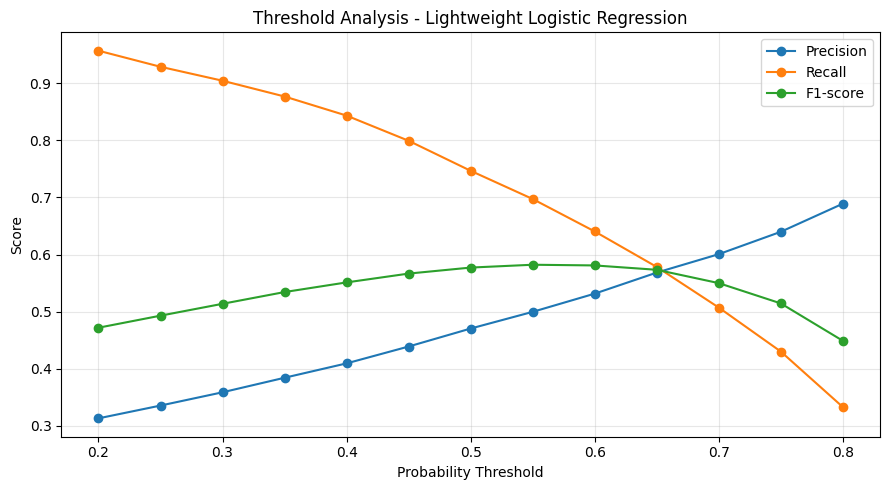

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Lightweight Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Insight

Analisis threshold menunjukkan bahwa perubahan probability threshold
menghasilkan trade-off antara Precision dan Recall.

Pada threshold **0,55**, model menghasilkan Precision **0,4996**,
Recall **0,6973**, dan F1-score **0,5821**. Sementara itu, threshold
yang lebih rendah seperti **0,40** meningkatkan Recall menjadi **0,8433**,
tetapi Precision menurun menjadi **0,4094**.

Hasil ini menunjukkan bahwa threshold merupakan parameter yang dapat
disesuaikan dengan kebutuhan sistem. Dalam EduPulse, threshold probabilitas
juga digunakan untuk membentuk kategori **Low Risk, Medium Risk, dan High Risk**
pada output aplikasi.

### Keputusan Threshold

Hasil out-of-fold threshold analysis menunjukkan adanya trade-off antara
Precision dan Recall. Semakin rendah probability threshold, Recall
cenderung meningkat, sedangkan Precision menurun.

Karena EduPulse digunakan sebagai early warning system, Recall menjadi
pertimbangan utama untuk mengurangi kemungkinan siswa dropout tidak
terdeteksi. Pada hasil pengujian, threshold **0.40** menghasilkan Recall
sebesar **0.8433** dengan Precision sebesar **0.4094** dan F1-score sebesar
**0.5512**.

Threshold **0.45** menghasilkan Recall sebesar **0.7993**, sedangkan
threshold **0.50** menghasilkan Recall sebesar **0.7467**. Oleh karena itu,
threshold **0.40** digunakan sebagai batas awal early warning karena
memberikan Recall di atas 0.80 pada hasil out-of-fold.

Sementara itu, threshold **0.70** digunakan sebagai batas untuk kategori
**High Risk** dalam interpretasi tiga tingkat risiko. Batas ini merupakan
aturan kategorisasi risiko dan bukan hasil optimasi binary threshold.

Dengan demikian, kategori risiko EduPulse ditetapkan sebagai berikut:

- **Low Risk**: probability < 0.40
- **Medium Risk**: 0.40 ≤ probability < 0.70
- **High Risk**: probability ≥ 0.70

Test set tidak digunakan dalam proses pemilihan threshold dan tetap
digunakan hanya untuk evaluasi akhir model.

In [37]:
# =========================
# FINAL RISK THRESHOLDS
# =========================

RISK_THRESHOLDS = {
    "high": 0.70,
    "medium": 0.40
}

print("Final Risk Thresholds:")
print("High Risk   :", RISK_THRESHOLDS["high"])
print("Medium Risk :", RISK_THRESHOLDS["medium"])
print("Low Risk    : < {:.2f}".format(RISK_THRESHOLDS["medium"]))

Final Risk Thresholds:
High Risk   : 0.7
Medium Risk : 0.4
Low Risk    : < 0.40


## **7.5 Train Final Model**

Pada tahap ini, model final dilatih menggunakan konfigurasi yang telah ditetapkan sebelumnya, yaitu **Logistic Regression** dengan **Lightweight Features**.

Data training digunakan untuk melatih model, sedangkan data testing tetap disimpan untuk proses evaluasi akhir pada tahap berikutnya.

In [38]:
# =========================
# TRAIN FINAL MAIN MODEL
# =========================

final_model = clone(models[FINAL_MODEL_NAME])

final_preprocessor = preprocessor_lightweight
final_features = FINAL_FEATURES

X_train_final = X_train_lightweight
X_test_final = X_test_lightweight

final_model.fit(X_train_final, y_train)

print("Final Model       :", FINAL_MODEL_NAME)
print("Final Feature Set :", FINAL_FEATURE_SET)
print("Jumlah input      :", len(final_features))
print("Input features    :", final_features)

Final Model       : Logistic Regression
Final Feature Set : Lightweight Features
Jumlah input      : 6
Input features    : ['GPA', 'Stress_Index', 'Attendance_Rate', 'Study_Hours_per_Day', 'Travel_Time_Minutes', 'Assignment_Delay_Days']


### Insight

Model final berhasil dikonfigurasi menggunakan **Logistic Regression** dengan enam fitur Lightweight. Data testing tidak digunakan untuk proses pelatihan dan akan digunakan pada tahap **Model Evaluation** untuk mengukur performa model pada data yang belum digunakan selama pengembangan.

# **8. Model Evaluation — Final Model**

Evaluasi akhir menggunakan test set yang tidak digunakan pada proses feature selection dan model comparison.

In [39]:
y_pred = final_model.predict(X_test_final)
y_prob = final_model.predict_proba(X_test_final)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

pd.DataFrame([final_metrics])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.7385,0.465969,0.755839,0.576518,0.816611


In [40]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Dropout", "Dropout"]
))

              precision    recall  f1-score   support

 Not Dropout       0.91      0.73      0.81      1529
     Dropout       0.47      0.76      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.74      0.69      2000
weighted avg       0.80      0.74      0.76      2000



### Insight

Evaluasi akhir pada test set menunjukkan bahwa model **Lightweight Logistic Regression** menghasilkan Accuracy sebesar **0,7385**, Precision sebesar **0,4660**, Recall sebesar **0,7558**, F1-score sebesar **0,5765**, dan ROC-AUC sebesar **0,8166**.

Recall sebesar **0,7558** menunjukkan bahwa model berhasil mendeteksi sekitar **75,6%** dari siswa yang termasuk kelas `Dropout` pada test set. Karena EduPulse digunakan sebagai **early warning system**, Recall menjadi salah satu metrik penting untuk melihat kemampuan model dalam menemukan siswa yang berpotensi dropout.

Precision sebesar **0,4660** menunjukkan bahwa tidak semua siswa yang diprediksi sebagai `Dropout` merupakan dropout aktual. Oleh karena itu, hasil prediksi model digunakan sebagai **informasi pendukung untuk monitoring dan intervensi awal**, bukan sebagai keputusan akhir terhadap kondisi siswa.

## **8.1 Confusion Matrix**

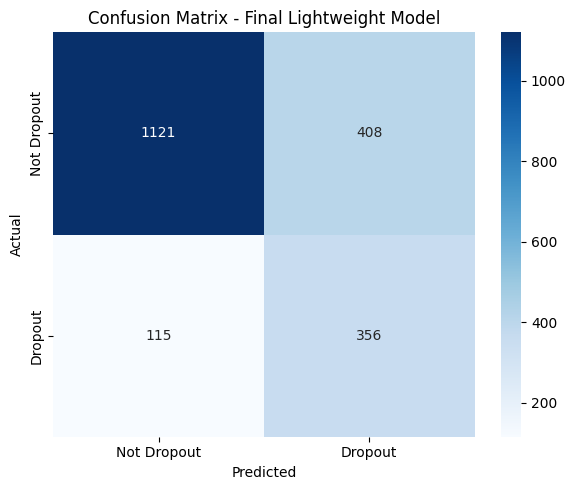

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Dropout", "Dropout"],
    yticklabels=["Not Dropout", "Dropout"]
)

plt.title("Confusion Matrix - Final Lightweight Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Insight

Confusion matrix menunjukkan hasil prediksi model pada test set yang terdiri dari **2.000 data siswa**.

Hasilnya menunjukkan:

- **1.121** siswa `Not Dropout` diprediksi dengan benar sebagai `Not Dropout` (**True Negative**).
- **356** siswa `Dropout` berhasil diprediksi dengan benar sebagai `Dropout` (**True Positive**).
- **408** siswa `Not Dropout` diprediksi sebagai `Dropout` (**False Positive**).
- **115** siswa `Dropout` diprediksi sebagai `Not Dropout` (**False Negative**).

Dalam konteks early warning, **False Negative** menjadi perhatian karena menunjukkan siswa yang secara aktual termasuk `Dropout`, tetapi tidak terdeteksi oleh model. Pada test set terdapat **115 kasus False Negative**.

Hasil ini sejalan dengan Recall sebesar **0,7558**, yang menunjukkan bahwa model mampu menangkap sebagian besar siswa pada kelas `Dropout`.

## **8.2 ROC Curve**

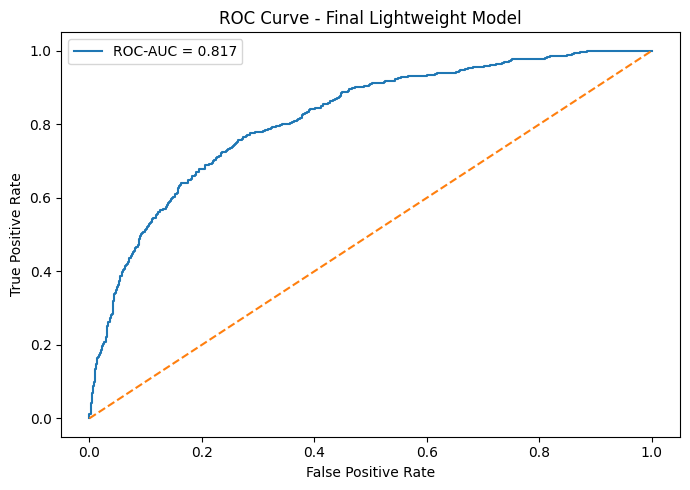

In [42]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_metrics['ROC-AUC']:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Final Lightweight Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Insight

ROC Curve digunakan untuk mengevaluasi kemampuan model dalam membedakan kelas `Dropout` dan `Not Dropout` pada berbagai probability threshold.

Model menghasilkan **ROC-AUC sebesar 0,8166** pada test set. Nilai tersebut menunjukkan bahwa model memiliki kemampuan diskriminasi yang baik dalam membedakan kedua kelas berdasarkan probabilitas prediksi yang dihasilkan.

ROC-AUC digunakan sebagai metrik tambahan karena evaluasi model tidak hanya bergantung pada satu nilai threshold klasifikasi.

## **8.3 Explanatory Analysis**

Evaluasi pada test set digunakan untuk mengetahui kemampuan model dalam
melakukan prediksi pada data yang tidak digunakan selama proses training.

Model **Logistic Regression dengan Lightweight Features** menghasilkan:

- **Accuracy:** 0,7385
- **Precision:** 0,4660
- **Recall:** 0,7558
- **F1-score:** 0,5765
- **ROC-AUC:** 0,8166

### Insight

Hasil evaluasi menunjukkan bahwa model memiliki **Recall sebesar 0,7558**, sehingga sebagian besar siswa yang termasuk kelas `Dropout` dapat terdeteksi oleh model.

Sementara itu, Precision sebesar **0,4660** menunjukkan bahwa terdapat sejumlah siswa yang diprediksi berisiko dropout tetapi secara aktual termasuk `Not Dropout`. Kondisi ini merupakan trade-off yang muncul ketika model lebih diarahkan untuk meningkatkan kemampuan mendeteksi siswa yang berisiko.

F1-score sebesar **0,5765** menunjukkan keseimbangan antara Precision dan Recall pada kelas `Dropout`.

ROC-AUC sebesar **0,8166** menunjukkan bahwa model memiliki kemampuan diskriminasi yang baik dalam membedakan siswa `Dropout` dan `Not Dropout`.

Secara keseluruhan, hasil evaluasi mendukung penggunaan **Lightweight Logistic Regression** sebagai komponen Machine Learning dalam EduPulse, khususnya untuk kebutuhan **early warning** dan monitoring siswa.

Perlu dibedakan antara evaluasi klasifikasi binary model dan interpretasi tingkat risiko. Metrik pada bagian evaluasi menggunakan prediksi binary dari model, sedangkan threshold **0,40** dan **0,70** digunakan untuk mengubah probabilitas dropout menjadi kategori risiko **Low Risk, Medium Risk, dan High Risk** pada fitur early warning.

Dengan demikian, threshold risk level tidak mengubah nilai metrik evaluasi binary yang telah dihitung sebelumnya.

# **9. Dropout Risk Interpretation**

In [43]:
def risk_level(probability):
    if probability >= RISK_THRESHOLDS["high"]:
        return "High Risk"
    elif probability >= RISK_THRESHOLDS["medium"]:
        return "Medium Risk"
    return "Low Risk"

risk_result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Dropout_Probability": y_prob
})

risk_result["Risk_Level"] = risk_result["Dropout_Probability"].apply(risk_level)

risk_summary = (
    risk_result["Risk_Level"]
    .value_counts()
    .reindex(["High Risk", "Medium Risk", "Low Risk"], fill_value=0)
    .rename_axis("Risk Level")
    .reset_index(name="Students")
)

risk_summary["Percentage"] = (
    risk_summary["Students"] / len(risk_result) * 100
).round(2)

risk_summary

,Risk Level,Students,Percentage
0,High Risk,399,19.95
1,Medium Risk,575,28.75
2,Low Risk,1026,51.30


### Insight

Hasil pengelompokan berdasarkan probabilitas dropout menunjukkan bahwa dari
**2.000 siswa pada test set**, terdapat:

- **399 siswa (19,95%)** dalam kategori **High Risk**
- **575 siswa (28,75%)** dalam kategori **Medium Risk**
- **1.026 siswa (51,30%)** dalam kategori **Low Risk**

Kategori risiko dibentuk berdasarkan probability threshold yang telah
ditentukan, yaitu:

- **Low Risk:** probabilitas dropout < **0,40**
- **Medium Risk:** probabilitas dropout **0,40–<0,70**
- **High Risk:** probabilitas dropout ≥ **0,70**

Pengelompokan ini digunakan untuk membantu menerjemahkan output probabilitas
model menjadi informasi yang lebih mudah digunakan dalam proses monitoring.

Kategori risiko tidak menunjukkan bahwa seorang siswa pasti mengalami dropout.
Hasil tersebut merupakan informasi pendukung yang dapat digunakan untuk
membantu menentukan siswa yang perlu mendapatkan perhatian atau pemantauan
lebih lanjut.

# **10. Conclusion & Recommendation**

- **Conclusion pertanyaan 1:**

**Evidence:**  
Hasil Exploratory Data Analysis menunjukkan bahwa beberapa indikator
memiliki pola perbedaan dropout rate. Pada `Attendance_Rate`, dropout rate
sebesar **38,60%** pada siswa dengan kehadiran di bawah 60% dan menurun
menjadi **13,96%** pada kelompok kehadiran 90–100%.

**Trend Analysis:**  
Dropout rate cenderung lebih tinggi pada kelompok dengan tingkat kehadiran
yang lebih rendah. Pola serupa juga terlihat pada `Study_Hours_per_Day`,
di mana dropout rate menurun dari **32,27%** pada siswa dengan waktu belajar
kurang dari 2 jam menjadi **17,76%** pada siswa dengan waktu belajar lebih
dari 6 jam.

**Actionable Insight:**  
Indikator kehadiran dan kebiasaan belajar dapat digunakan sebagai salah satu
informasi pendukung dalam proses early warning untuk membantu mengidentifikasi
siswa yang membutuhkan pemantauan lebih lanjut.

- **Conclusion pertanyaan 2:**

**Evidence:**  
Hasil feature importance menunjukkan bahwa `GPA`, `Semester_GPA`, dan `CGPA`
memiliki importance tertinggi. Selain itu, `Stress_Index`,
`Attendance_Rate`, `Study_Hours_per_Day`, dan `Travel_Time_Minutes` juga
memiliki importance yang relatif tinggi.

**Trend Analysis:**  
Beberapa indikator akademik memiliki informasi yang saling redundant,
terutama `GPA`, `Semester_GPA`, dan `CGPA`. Oleh karena itu, tidak seluruh
fitur digunakan pada model Lightweight.

**Actionable Insight:**  
Sebanyak enam fitur dipilih sebagai input Lightweight Model, yaitu `GPA`,
`Stress_Index`, `Attendance_Rate`, `Study_Hours_per_Day`,
`Travel_Time_Minutes`, dan `Assignment_Delay_Days`. Pemilihan ini membuat
jumlah input lebih sederhana untuk kebutuhan integrasi aplikasi tanpa harus
mengirimkan seluruh fitur pada dataset.

- **Conclusion pertanyaan 3:**

**Evidence:**  
Hasil Stratified 5-Fold Cross Validation menunjukkan bahwa Lightweight
Logistic Regression menghasilkan Accuracy **0,7425**, Recall **0,7467**,
F1-score **0,5770**, dan ROC-AUC **0,8203**.

Pada evaluasi test set, model menghasilkan Accuracy **0,7385**, Precision
**0,4660**, Recall **0,7558**, F1-score **0,5765**, dan ROC-AUC **0,8166**.

**Trend Analysis:**  
Pada konfigurasi Lightweight Features, Logistic Regression memiliki Recall
yang lebih tinggi dibandingkan model lain yang diuji, meskipun Accuracy-nya
lebih rendah dibandingkan Gradient Boosting dan Random Forest.

**Actionable Insight:**  
Karena EduPulse digunakan sebagai **early warning system**, kemampuan
mendeteksi siswa pada kelas `Dropout` menjadi pertimbangan penting. Oleh
karena itu, konfigurasi **Lightweight Features + Logistic Regression**
digunakan sebagai model utama EduPulse.

### **Rekomendasi Action Item**

- **Meningkatkan monitoring siswa berisiko:**  
  Menggunakan hasil `Dropout Probability` dan `Risk Level` sebagai informasi
  pendukung untuk membantu sekolah menentukan siswa yang memerlukan
  pemantauan dan intervensi awal.

- **Mengembangkan fitur intervensi:**  
  Mengembangkan rekomendasi tindakan yang lebih spesifik berdasarkan faktor
  risiko siswa, seperti masalah kehadiran, kebiasaan belajar, stres, atau
  keterlambatan tugas.

- **Menambahkan data yang lebih relevan:**  
  Pada pengembangan berikutnya, model dapat menggunakan data historis
  beberapa semester, aktivitas pembelajaran, serta indikator akademik dan
  non-akademik lainnya untuk memperkaya informasi prediksi.

- **Melakukan evaluasi dan pengembangan model secara berkala:**  
  Model dapat diuji kembali menggunakan data siswa terbaru serta dilakukan
  hyperparameter tuning dan evaluasi threshold untuk menyesuaikan model
  dengan kebutuhan sistem early warning.

- **Mengembangkan penggunaan data aktual:**  
  Model dapat divalidasi menggunakan data aktual dari institusi pendidikan
  untuk mengetahui performanya pada kondisi operasional yang sebenarnya.

In [44]:
print("=== FINAL MODEL SUMMARY ===")

print("Model        :", FINAL_MODEL_NAME)
print("Feature Set  :", FINAL_FEATURE_SET)
print("Jumlah input :", len(FINAL_FEATURES))

final_cv_row = cv_lightweight_results[
    cv_lightweight_results["Model"] == FINAL_MODEL_NAME
].iloc[0]

print("\nCV Metrics:")
print("Accuracy     :", round(final_cv_row["Accuracy"], 4))
print("Precision    :", round(final_cv_row["Precision"], 4))
print("Recall       :", round(final_cv_row["Recall"], 4))
print("F1           :", round(final_cv_row["F1"], 4))
print("ROC-AUC      :", round(final_cv_row["ROC-AUC"], 4))

print("\nTest Metrics:")
for metric, value in final_metrics.items():
    print(f"{metric:10s}: {value:.4f}")

=== FINAL MODEL SUMMARY ===
Model        : Logistic Regression
Feature Set  : Lightweight Features
Jumlah input : 6

CV Metrics:
Accuracy     : 0.7425
Precision    : 0.4704
Recall       : 0.7467
F1           : 0.577
ROC-AUC      : 0.8203

Test Metrics:
Accuracy  : 0.7385
Precision : 0.4660
Recall    : 0.7558
F1        : 0.5765
ROC-AUC   : 0.8166


# **11. Export Models**

Model utama EduPulse diekspor dalam bentuk artifact `edupulse_dropout_model.joblib`
untuk digunakan pada proses integrasi antara aplikasi Fullstack dan komponen
Machine Learning.

Artifact yang disimpan merupakan **Lightweight Logistic Regression** dengan
enam fitur utama:

- `GPA`
- `Stress_Index`
- `Attendance_Rate`
- `Study_Hours_per_Day`
- `Travel_Time_Minutes`
- `Assignment_Delay_Days`

Artifact juga menyimpan preprocessing dan konfigurasi yang diperlukan agar
model dapat menerima input dari aplikasi dan menghasilkan prediksi risiko
dropout secara konsisten.

Model **Full Features** tetap digunakan sebagai baseline pada tahap eksperimen
dan evaluasi, tetapi tidak diekspor sebagai artifact untuk deployment aplikasi.

In [45]:
# =========================
# EXPORT MAIN MODEL
# =========================

main_model = clone(final_model)

main_model.fit(
    X_train_lightweight,
    y_train
)

main_pipeline = {
    "preprocessor": preprocessor_lightweight,
    "model": main_model,
    "features": FINAL_FEATURES,
    "target": target_col,
    "risk_thresholds": RISK_THRESHOLDS
}

joblib.dump(
    main_pipeline,
    "edupulse_dropout_model.joblib"
)

print("=== MAIN MODEL EXPORTED ===")
print("Model       :", FINAL_MODEL_NAME)
print("Feature Set :", FINAL_FEATURE_SET)
print("Features    :", FINAL_FEATURES)

=== MAIN MODEL EXPORTED ===
Model       : Logistic Regression
Feature Set : Lightweight Features
Features    : ['GPA', 'Stress_Index', 'Attendance_Rate', 'Study_Hours_per_Day', 'Travel_Time_Minutes', 'Assignment_Delay_Days']


In [46]:
from google.colab import files

files.download("edupulse_dropout_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Insight

Model utama berhasil diekspor sebagai `edupulse_dropout_model.joblib`.

Artifact tersebut berisi:

- **Preprocessor** untuk melakukan transformasi input.
- **Model Logistic Regression** sebagai model prediksi utama.
- **Feature List** yang menentukan enam input yang dibutuhkan aplikasi.
- **Target** yang digunakan dalam pemodelan.
- **Risk Thresholds** yang digunakan untuk menentukan kategori Low Risk,
  Medium Risk, dan High Risk.

Dengan struktur tersebut, artifact dapat digunakan kembali pada aplikasi
EduPulse tanpa perlu melakukan proses training ulang setiap kali aplikasi
dijalankan.

# **12. predict.py**

`predict_dropout()` adalah fungsi utama untuk melakukan prediksi menggunakan
model Lightweight Logistic Regression dengan enam input.

In [47]:
%%writefile predict.py

import joblib
import pandas as pd

MAIN_MODEL_PATH = "edupulse_dropout_model.joblib"

main_pipeline = joblib.load(MAIN_MODEL_PATH)


def predict_dropout(student_data):
    """
    Predict dropout probability and risk level
    using the main Lightweight Logistic Regression model.
    """

    features = main_pipeline["features"]
    preprocessor = main_pipeline["preprocessor"]
    model = main_pipeline["model"]
    thresholds = main_pipeline["risk_thresholds"]

    input_df = pd.DataFrame([student_data])

    missing_features = [
        feature
        for feature in features
        if feature not in input_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features for this model: {missing_features}"
        )

    input_df = input_df[features]

    X_input = preprocessor.transform(input_df)

    probability = float(
        model.predict_proba(X_input)[0, 1]
    )

    if probability >= thresholds["high"]:
        risk = "High Risk"
    elif probability >= thresholds["medium"]:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"

    return {
        "dropout_probability": probability,
        "risk_level": risk
    }

Writing predict.py


In [48]:
from google.colab import files

files.download("predict.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Reload module agar menggunakan predict.py versi terbaru

import importlib
import predict

importlib.reload(predict)

from predict import predict_dropout

print("Prediction function berhasil diimport ulang.")

Prediction function berhasil diimport ulang.


## **12.1 Example Prediction — Main Lightweight Model**

In [50]:
example_student_lightweight = {
    "GPA": 2.0,
    "Stress_Index": 7.0,
    "Attendance_Rate": 70.0,
    "Study_Hours_per_Day": 2.0,
    "Travel_Time_Minutes": 45.0,
    "Assignment_Delay_Days": 4.0
}

prediction = predict_dropout(example_student_lightweight)

print("Dropout Probability:", round(prediction["dropout_probability"], 4))
print("Risk Level:", prediction["risk_level"])

Dropout Probability: 0.7512
Risk Level: High Risk
